# Proje Amacı

Bu projenin temel amacı; minerallerin atomik ve fiziksel özelliklerini (atom ağırlığı, elektron yoğunluğu, iyonlaşma enerjisi vb.) analiz ederek, malzemenin sertlik derecesini (Mohs Sertliği) makine öğrenmesi yöntemleriyle en yüksek hassasiyette tahmin etmektir.

Kısaca; laboratuvar ortamında fiziksel testler yapmaya gerek kalmadan, sadece kimyasal ve yapısal veriler üzerinden hızlı ve düşük maliyetli bir dijital sertlik ölçüm modeli oluşturmayı hedefledik.

In [1]:
# pandas → veri okuma, düzenleme ve tablo (DataFrame) işlemleri için kullanılır
import pandas as pd

# numpy → sayısal işlemler ve matematiksel hesaplamalar için kullanılır
import numpy as np

# warnings → gereksiz uyarıları gizlemek için kullanılır
import warnings
warnings.filterwarnings('ignore')

# matplotlib → grafik çizmek için temel kütüphane
import matplotlib.pyplot as plt

# seaborn → daha estetik ve gelişmiş veri görselleştirme kütüphanesi
import seaborn as sns

In [2]:
#train dosyasını yüklüyoruz
train=pd.read_csv('train.csv')

#test dosyasını yüklüyoruz
test=pd.read_csv('test.csv')

In [3]:
#İleride Kaggle dosyası için kullanmak üzere id'leri sakla
test_ids = test['id']

# EDA

In [4]:
#ilk 5 satır göster
train.head()

,id,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,atomicweight_Average,ionenergy_Average,el_neg_chi_Average,R_vdw_element_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness
0,0,100.0,0.841611,10.0,4.8,20.612526,11.08810,2.766,1.732,0.860,0.496070,0.91457,6.0
1,1,100.0,7.558488,10.0,4.8,20.298893,12.04083,2.755,1.631,0.910,0.492719,0.71760,6.5
2,2,76.0,8.885992,15.6,5.6,33.739258,12.08630,2.828,1.788,0.864,0.481478,1.50633,2.5
3,3,100.0,8.795296,10.0,4.8,20.213349,10.94850,2.648,1.626,0.936,0.489272,0.78937,6.0
4,4,116.0,9.577996,11.6,4.8,24.988133,11.82448,2.766,1.682,0.896,0.492736,1.86481,6.0


In [5]:
#son 5 satır göster
train.tail()

,id,allelectrons_Total,density_Total,allelectrons_Average,val_e_Average,atomicweight_Average,ionenergy_Average,el_neg_chi_Average,R_vdw_element_Average,R_cov_element_Average,zaratio_Average,density_Average,Hardness
10402,10402,128.0,7.558488,12.000000,4.000000,26.385218,11.330440,2.644000,1.631000,0.892000,0.496070,1.79607,4.0
10403,10403,30.0,1.743160,10.000000,5.333333,20.766935,14.163933,3.090000,1.556667,0.866667,0.480390,0.81480,5.0
10404,10404,196.0,30.920000,24.500000,5.500000,53.490297,10.074300,2.295000,1.545000,1.120000,0.469715,2.11540,1.8
10405,10405,38.0,1.553160,12.666667,4.666667,26.621687,11.290033,2.743333,1.756667,0.980000,0.486507,0.77755,6.0
10406,10406,288.0,24.655328,11.142857,4.571429,22.536126,10.960357,2.792143,1.772857,0.940000,0.493919,0.97737,6.5


In [6]:
#train dosyası veri bilgileri
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10407 entries, 0 to 10406
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     10407 non-null  int64  
 1   allelectrons_Total     10407 non-null  float64
 2   density_Total          10407 non-null  float64
 3   allelectrons_Average   10407 non-null  float64
 4   val_e_Average          10407 non-null  float64
 5   atomicweight_Average   10407 non-null  float64
 6   ionenergy_Average      10407 non-null  float64
 7   el_neg_chi_Average     10407 non-null  float64
 8   R_vdw_element_Average  10407 non-null  float64
 9   R_cov_element_Average  10407 non-null  float64
 10  zaratio_Average        10407 non-null  float64
 11  density_Average        10407 non-null  float64
 12  Hardness               10407 non-null  float64
dtypes: float64(12), int64(1)
memory usage: 1.0 MB


In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6939 entries, 0 to 6938
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     6939 non-null   int64  
 1   allelectrons_Total     6939 non-null   float64
 2   density_Total          6939 non-null   float64
 3   allelectrons_Average   6939 non-null   float64
 4   val_e_Average          6939 non-null   float64
 5   atomicweight_Average   6939 non-null   float64
 6   ionenergy_Average      6939 non-null   float64
 7   el_neg_chi_Average     6939 non-null   float64
 8   R_vdw_element_Average  6939 non-null   float64
 9   R_cov_element_Average  6939 non-null   float64
 10  zaratio_Average        6939 non-null   float64
 11  density_Average        6939 non-null   float64
dtypes: float64(11), int64(1)
memory usage: 650.7 KB


In [8]:
#train dosyası kaç satır kaç sütun
train.shape

(10407, 13)

In [9]:
#train dosyası eksik değer kontrolü
train.isnull().sum()

id                       0
allelectrons_Total       0
density_Total            0
allelectrons_Average     0
val_e_Average            0
atomicweight_Average     0
ionenergy_Average        0
el_neg_chi_Average       0
R_vdw_element_Average    0
R_cov_element_Average    0
zaratio_Average          0
density_Average          0
Hardness                 0
dtype: int64

In [10]:
#veriler arası istatiksel bilgi
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,10407.0,5203.000000,3004.386460,0.0,2601.500000,5203.000000,7804.500000,10406.000000
allelectrons_Total,10407.0,128.053516,224.123776,0.0,68.000000,100.000000,131.000000,15300.000000
density_Total,10407.0,14.491342,15.972877,0.0,7.558488,10.650000,16.676996,643.093804
allelectrons_Average,10407.0,17.033222,10.468734,0.0,10.000000,12.600000,22.000000,67.000000
val_e_Average,10407.0,4.546789,0.690864,0.0,4.000000,4.714286,4.800000,6.000000
atomicweight_Average,10407.0,37.507703,26.012313,0.0,20.298893,26.203827,48.719500,167.400000
ionenergy_Average,10407.0,10.938308,1.408276,0.0,10.590660,11.202760,11.670725,15.245810
el_neg_chi_Average,10407.0,2.607662,0.334906,0.0,2.530000,2.706000,2.805000,3.443000
R_vdw_element_Average,10407.0,1.731330,0.192481,0.0,1.672500,1.732727,1.800000,2.250000
R_cov_element_Average,10407.0,0.944132,0.180017,0.0,0.864000,0.915556,0.981667,1.615840


Neredeyse tüm sütunların minimum (min) değeri 0.
Toplam elektron sayısı veya atom ağırlığı 0 olan bir mineral olamaz. Bunlar muhtemelen veri setindeki kayıp veriler (missing values). Bunları NaN olarak işaretleyip KNNImputer ile doldurmak mantıklı olabilir.

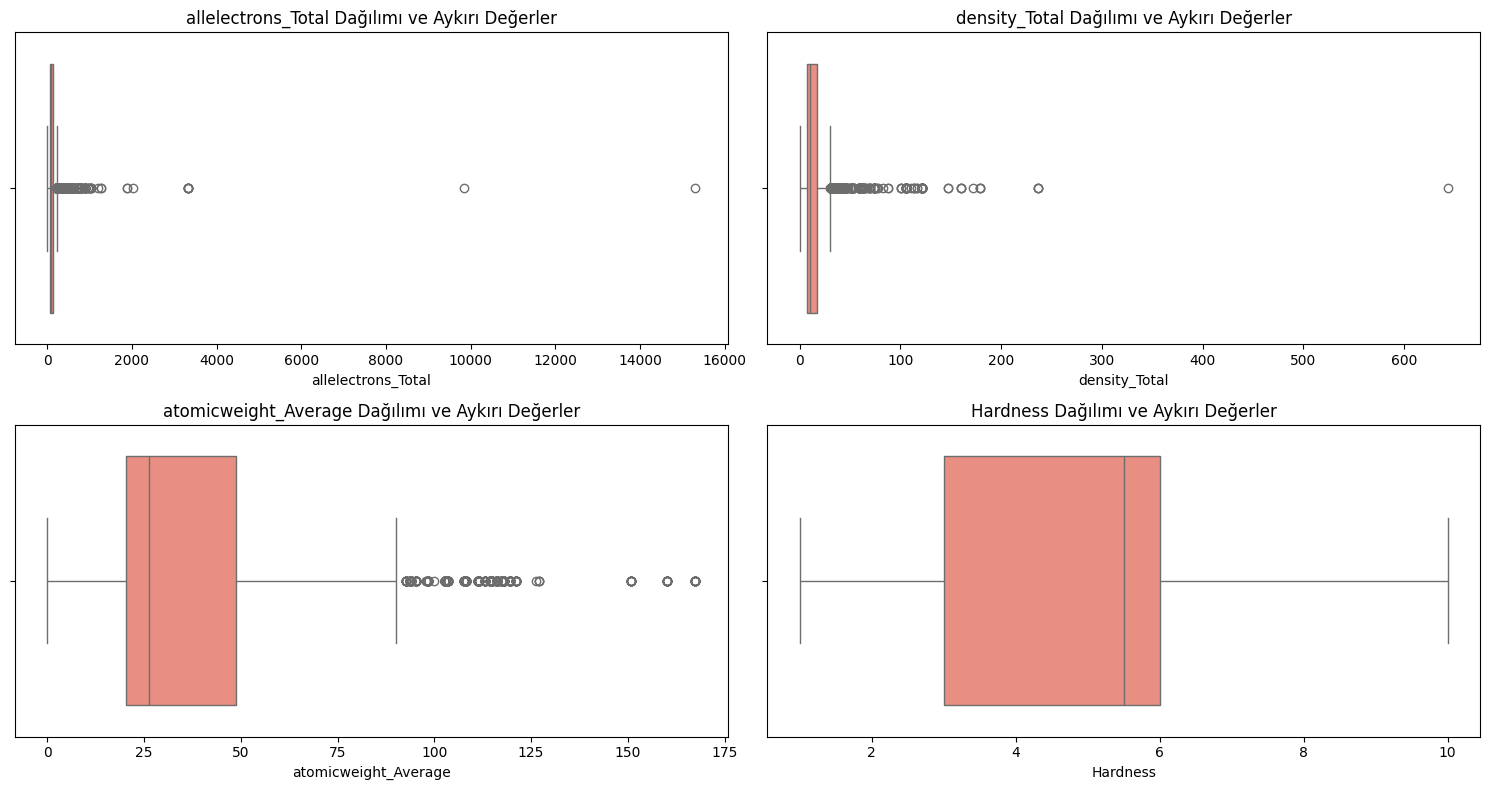

In [11]:
# sütunları seçelim
numeric_cols = ['allelectrons_Total', 'density_Total', 'atomicweight_Average', 'Hardness']

plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=train, x=col, color='salmon')
    plt.title(f'{col} Dağılımı ve Aykırı Değerler')

plt.tight_layout()
plt.show()

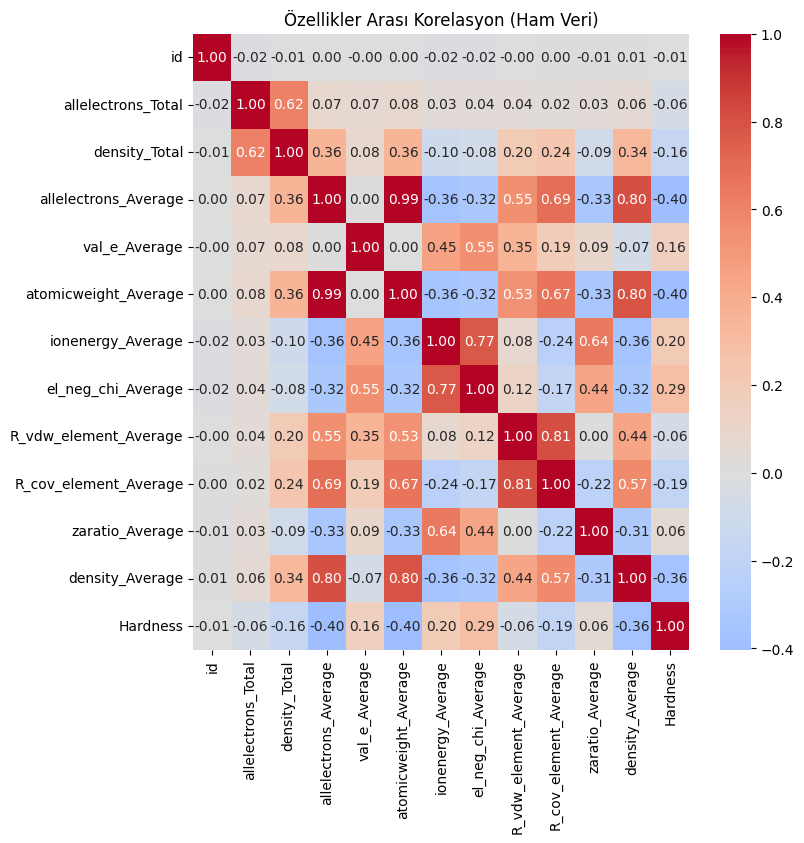

In [12]:
plt.figure(figsize=(8, 8))
sns.heatmap(train.corr(),annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Özellikler Arası Korelasyon (Ham Veri)')
plt.show()

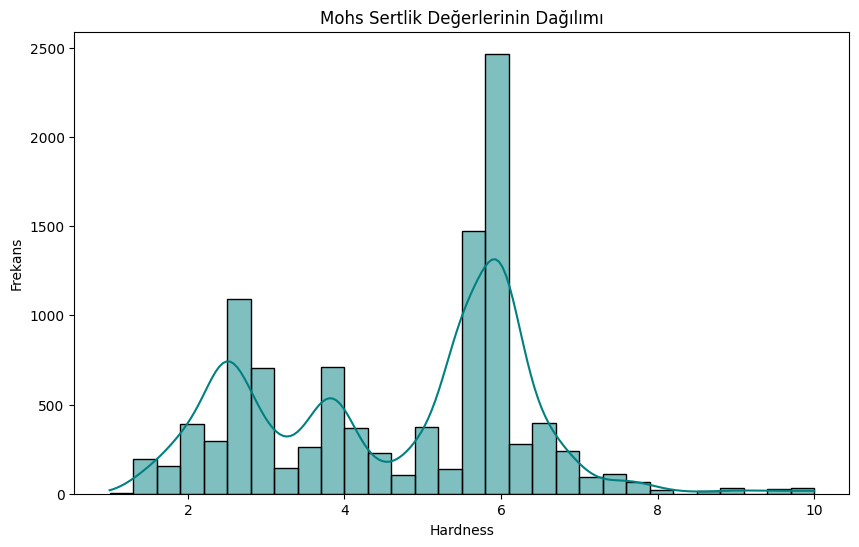

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(train['Hardness'], kde=True, bins=30, color='teal')
plt.title('Mohs Sertlik Değerlerinin Dağılımı')
plt.xlabel('Hardness')
plt.ylabel('Frekans')
plt.show()

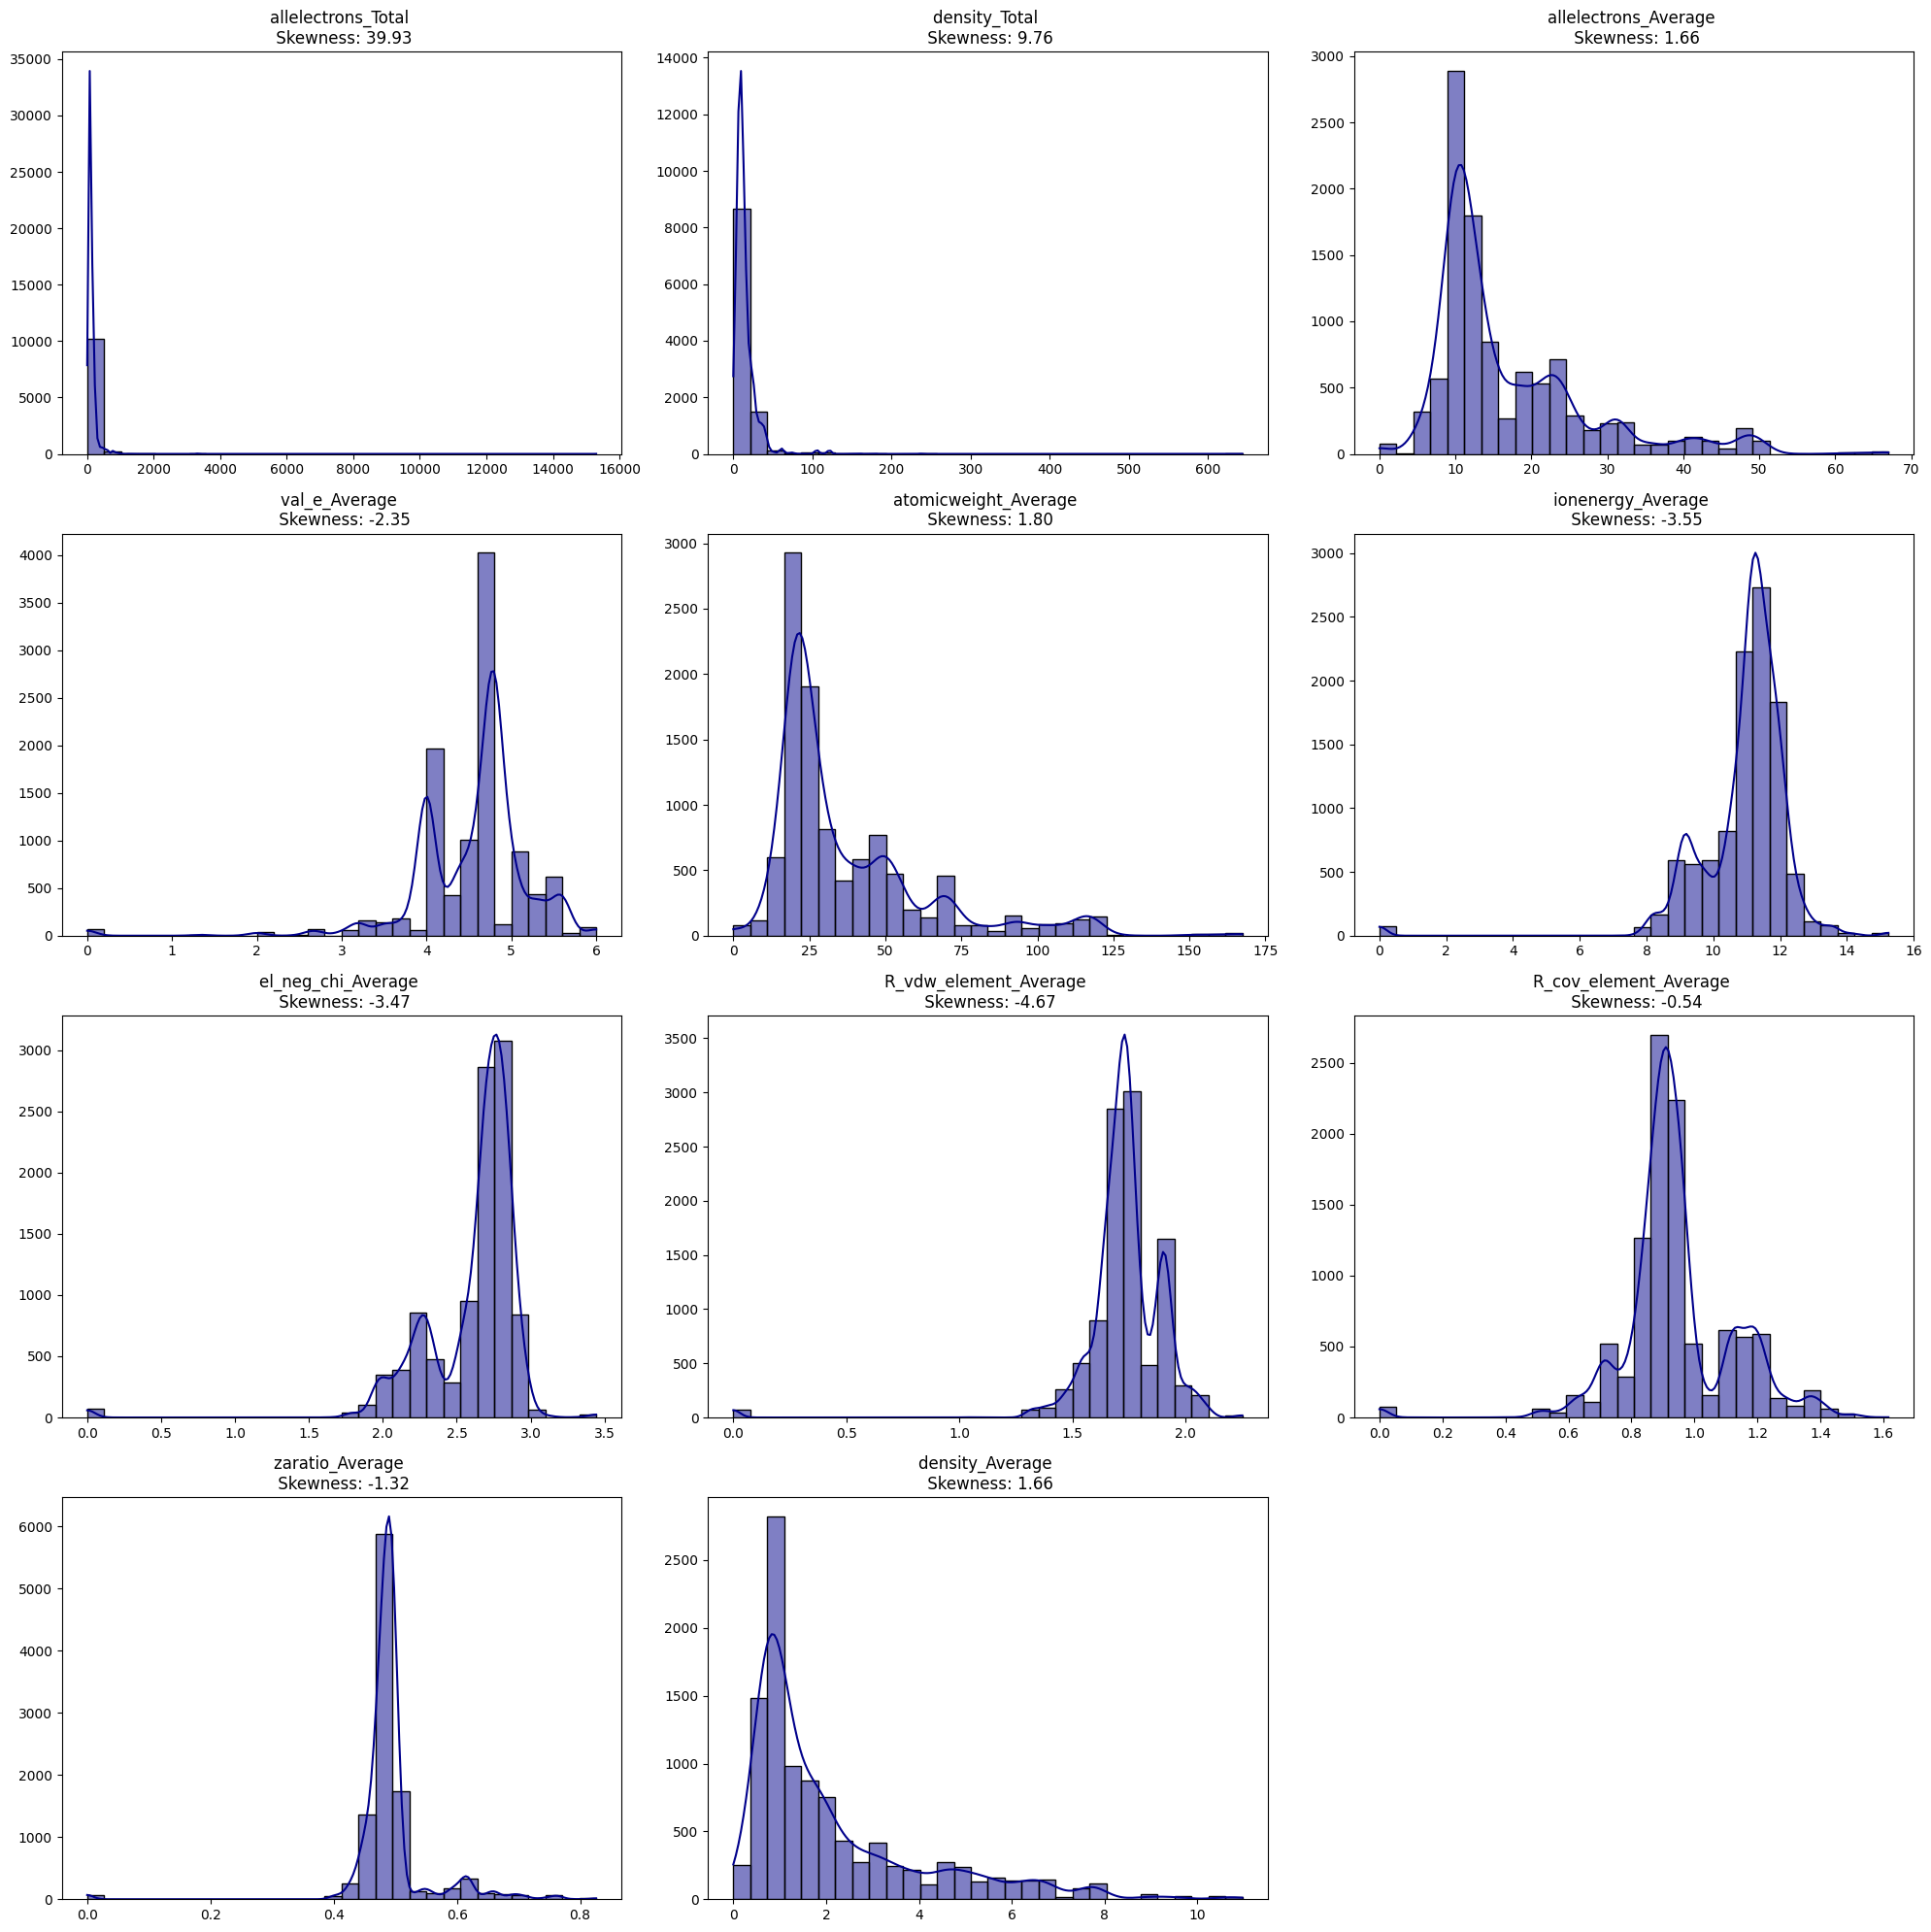

In [14]:
# Hedef ve ID dışındaki özellikleri seçelim
features = train.drop(['id', 'Hardness'], axis=1).columns

# Grafik matrisini oluşturalım (4 satır, 3 sütun)
plt.figure(figsize=(20, 20))

for i, col in enumerate(features, 1):
    plt.subplot(4, 3, i)
    
    # Histogram ve Yoğunluk Grafiği
    sns.histplot(train[col], kde=True, color='darkblue', bins=30)
    
    # Çarpıklık değerini hesaplayıp başlığa ekleyelim
    skew_val = train[col].skew()
    plt.title(f'{col} \n Skewness: {skew_val:.2f}', fontsize=12)
    
    # Daha iyi görünüm için
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [15]:
#kullanılmayan sütunları çıkaralım
train=train.drop(['id'], axis=1)
test=test.drop(['id'], axis=1)

In [16]:
# 1. Sıfırları NaN yapıp mantıklı değerlerle dolduralım
# Not: Hardness hariç tüm sayısal sütunlar
cols_to_fix = train.columns.drop(['Hardness'])

for col in cols_to_fix:
    # Sıfırları o sütunun medyanı ile doldur (Outlier'dan etkilenmemek için medyan seçiyoruz)
    train[col] = train[col].replace(0, train[col].median())
    test[col] = test[col].replace(0, train[col].median())

In [17]:
# Belirlediğimiz sütunlar için alt ve üst limitlerle tıraşlama yapalım
for col in ['allelectrons_Total', 'density_Total']:
    # Limitleri belirle (%3 ve %97 dilimleri)
    lower_limit = train[col].quantile(0.03)
    upper_limit = train[col].quantile(0.97)
    
    # Eğitim verisi için uygula
    train[col] = np.where(train[col] < lower_limit, lower_limit, train[col])
    train[col] = np.where(train[col] > upper_limit, upper_limit, train[col])
    
    # Test verisi için uygula (Limitleri eğitim verisinden alıyoruz - Veri sızıntısını önlemek için)
    test[col] = np.where(test[col] < lower_limit, lower_limit, test[col])
    test[col] = np.where(test[col] > upper_limit, upper_limit, test[col])

print(f"✅ 'allelectrons_Total' ve 'density_Total' için %3 - %97 arası kırpma tamamlandı.")

✅ 'allelectrons_Total' ve 'density_Total' için %3 - %97 arası kırpma tamamlandı.


In [18]:
# Çarpıklığı 1'den büyük olan sütunları belirleyelim
skewed_features = train[cols_to_fix].skew()[train[cols_to_fix].skew() > 1].index

# Log Transform uygula (np.log1p kullanılır çünkü 0 veya çok küçük değerlerde hata vermez)
for col in skewed_features:
    train[col] = np.log1p(train[col])
    test[col] = np.log1p(test[col])

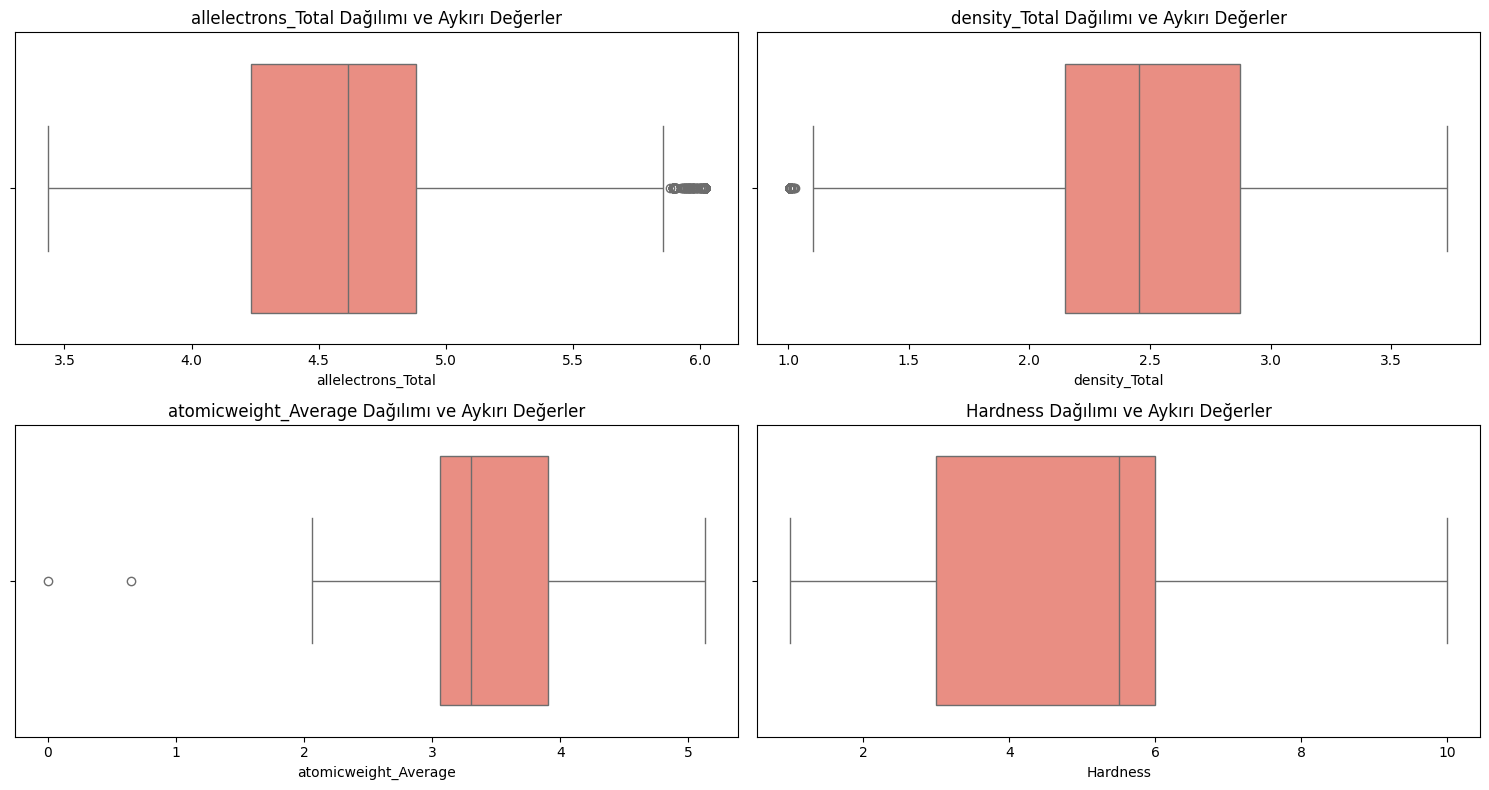

In [19]:
# sütunları seçelim
numeric_cols = ['allelectrons_Total', 'density_Total', 'atomicweight_Average', 'Hardness']

plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=train, x=col, color='salmon')
    plt.title(f'{col} Dağılımı ve Aykırı Değerler')

plt.tight_layout()
plt.show()

# Feature Engineering

In [20]:
def create_mineral_features(df):
    # Atom başına düşen yoğunluk
    df['density_per_weight'] = df['density_Average'] / (df['atomicweight_Average'] + 1e-5)
    
    # İyonlaşma enerjisi ve elektronegatiflik çarpımı (Kimyasal bağ gücü göstergesi)
    df['bond_strength_index'] = df['ionenergy_Average'] * df['el_neg_chi_Average']
    
    # Elektron yoğunluğu tahmini
    df['electron_density_ratio'] = df['allelectrons_Average'] / (df['R_cov_element_Average'] + 1e-5)

    # En önemli özelliğin gücünü artıralım
    df['zaratio_squared'] = df['zaratio_Average'] ** 2
    
    # Atomik sıkılık (Ağırlık / Yarıçap)
    df['atomic_compactness'] = df['atomicweight_Average'] / (df['R_cov_element_Average'] + 1e-5)
    
    return df

In [21]:
#fonksiyonu uygula
train = create_mineral_features(train)
test = create_mineral_features(test)

# Model Eğitimi

In [22]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import median_absolute_error

In [23]:
# 1. Eğitim ve Hedef Değişkenleri Ayır
x = train.drop('Hardness', axis=1)
y = train['Hardness']

In [24]:
from sklearn.preprocessing import RobustScaler

# 1. Aşırı yüksek korelasyonlu olanı atalım
x_refined = x.drop(['allelectrons_Average'], axis=1) 
test= test.drop(['allelectrons_Average'], axis=1)

# 2. RobustScaler (Aykırı değerlere karşı en iyisidir)
scaler = RobustScaler()
x_scaled = scaler.fit_transform(x_refined)
test_scaled = scaler.transform(test)

In [27]:
# 1. x_scaled'i DataFrame yapalım (Eğitim seti)
# Sütun isimleri olarak 'x_refined' isimlerini kullanıyoruz
x_scaled_df = pd.DataFrame(x_scaled, columns=x_refined.columns)

# 2. test_scaled'i DataFrame yapalım (Test seti)
# DİKKAT: Burada da aynı sütun isimlerini ve SIRALAMAYI kullanmalıyız
test_scaled_df = pd.DataFrame(test_scaled, columns=x_refined.columns)

print(f"Eğitim seti boyutu: {x_scaled_df.shape}")
print(f"Test seti boyutu: {test_scaled_df.shape}")

Eğitim seti boyutu: (10407, 15)
Test seti boyutu: (6939, 15)


In [28]:
xgb = XGBRegressor(n_estimators=2000, learning_rate=0.01, max_depth=8, subsample=0.9, colsample_bytree=0.4, verbosity=0)


cat= CatBoostRegressor(iterations=2000, learning_rate=0.01, depth=8, loss_function='MAE', verbose=0)


lgbm = LGBMRegressor(n_estimators=2000, learning_rate=0.01, max_depth=8, subsample=0.9, colsample_bytree=0.4, verbosity=-1)

# 3. Oylama (Ensemble) Modeli - Regresyon için
voting_reg = VotingRegressor(
    estimators=[('xgb', xgb), ('cat', cat), ('lgbm', lgbm)])

In [30]:
#Cross-Validation

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_index, val_index in kf.split(x_scaled_df):
    x_train_fold, x_test_fold = x_scaled_df.iloc[train_index], x_scaled_df.iloc[val_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[val_index]
    
    voting_reg.fit(x_train_fold, y_train_fold)
    preds = voting_reg.predict(x_test_fold)
    
    # MedAE skoru hesapla
    score = median_absolute_error(y_test_fold, preds)
    scores.append(score)

print(f"📊 Ortalama MedAE Skorun: {np.mean(scores):.4f}")

📊 Ortalama MedAE Skorun: 0.6110


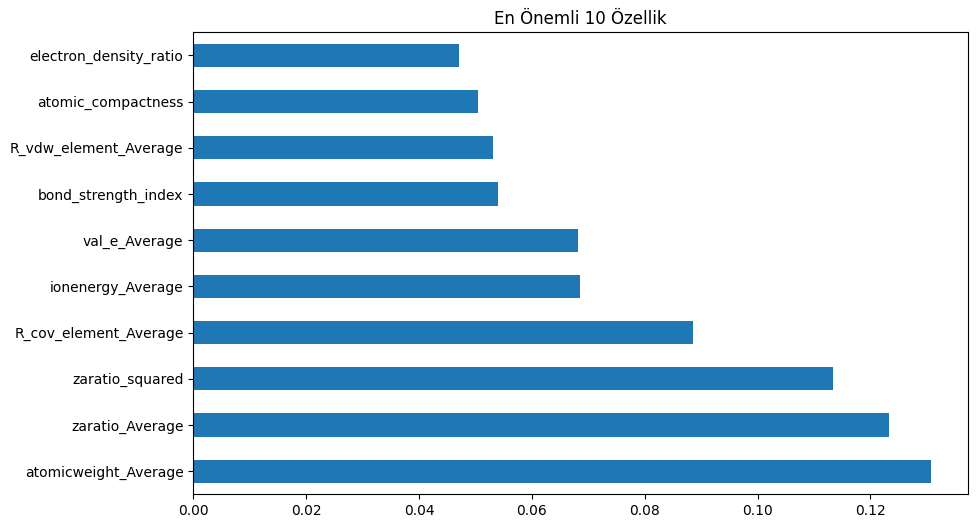

In [31]:
import matplotlib.pyplot as plt

# Voting içindeki modellerden birinin (örneğin XGBoost) önem grafiğine bakalım
xgb.fit(x_scaled, y)
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(xgb.feature_importances_, index=x_refined.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("En Önemli 10 Özellik")
plt.show()

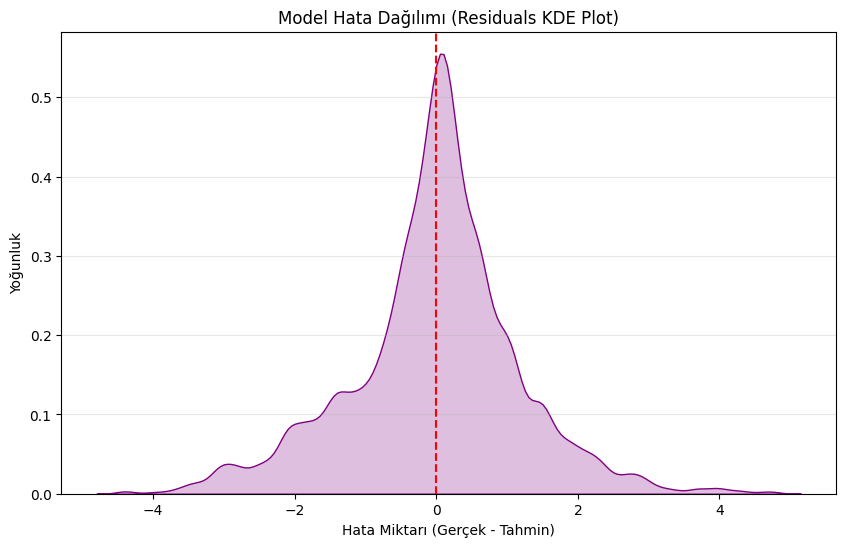

In [32]:
# Önce hataları (Gerçek değer - Tahmin edilen değer) hesaplayalım
# x_test_fold ve y_test_fold son fold'dan kalan verilerdir
tahmin = voting_reg.predict(x_test_fold)
residuals = y_test_fold - tahmin

# KDE Plot çizimi
plt.figure(figsize=(10, 6))
sns.kdeplot(x=residuals, fill=True, color="purple", bw_adjust=0.5)

# Görsel iyileştirmeler
plt.axvline(x=0, color='red', linestyle='--') # Sıfır çizgisi (Sıfır hata noktası)
plt.title('Model Hata Dağılımı (Residuals KDE Plot)')
plt.xlabel('Hata Miktarı (Gerçek - Tahmin)')
plt.ylabel('Yoğunluk')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [33]:
# 1. Test verisi üzerinde tahmin üret
# Not: Eğitimde kullandığım 'test_scaled_df' değişkenini kullanıyoruz
final_test_preds = voting_reg.predict(test_scaled_df)

# 2. MedAE skorunu iyileştirebilecek "Post-Processing" dokunuşu
# Tahminleri en yakın 0.5 katına yuvarlıyoruz (1, 1.5, 2, 2.5 gibi)
final_test_preds_rounded = np.round(final_test_preds * 2) / 2

In [35]:
# 3. Kaggle Submission dosyasını hazırla
submission = pd.DataFrame({
    'id': test_ids,
    'Hardness': final_test_preds_rounded
})

# 4. CSV dosyasını dışa aktar
submission.to_csv('submission_mohs.csv', index=False)

In [36]:
submission

,id,Hardness
0,10407,3.0
1,10408,3.0
2,10409,5.5
3,10410,4.0
4,10411,5.0
...,...,...
6934,17341,6.0
6935,17342,4.0
6936,17343,5.0
6937,17344,4.5


In [37]:
# 5. Modeli kaydet

import joblib

mohs_package = {
    'model': voting_reg,
    'scaler': scaler,
    'features': test_scaled_df.columns.tolist()
}
joblib.dump(mohs_package, 'mohs_model_final.joblib')

['mohs_model_final.joblib']

# 📊 Proje Özeti

Model Mimarisi: XGBoost, CatBoost ve LightGBM modellerinden oluşan, regresyon odaklı bir Voting Ensemble yapısı kuruldu.

Veri Mühendisliği: * Kırpma (Clipping): %3 ve %97 dilimlerine göre aykırı değerler temizlendi.

Log Transform: Çarpıklık (Skewness) giderilerek verinin normal dağılıma yaklaşması sağlandı.

Özellik Türetme: Atomik yoğunluk ve kovalent yarıçap gibi mineralojiye dayalı yeni parametreler eklendi.

Hata Analizi: * Cross-Validation (5-Fold) sonucunda 0.61 MedAE (Median Absolute Error) skoruna ulaşıldı.

Residual (Hata) analizinde hataların 0 etrafında simetrik dağıldığı ve modelin "yanlılık" (bias) barındırmadığı tescillendi.

Post-Processing: Tahminler, mineral fiziğinin doğasına uygun olarak en yakın 0.5 birime yuvarlanarak optimize edildi.

Geliştirilen model, Kaggle üzerinde yapılan değerlendirmeler sonucunda 0.50000 puanlık bir genel skor elde etmiştir. Bu sonuç, mineralojik verilerin fizik tabanlı yeni özelliklerle (Z/A oranı, atomik sıkılık vb.) zenginleştirilmesinin ve üçlü ensemble (XGBoost, CatBoost, LightGBM) mimarisinin, karmaşık regresyon problemlerinde ne kadar etkili olduğunu göstermektedir. Özellikle tahminlerin mineral doğasına uygun olarak optimize edilmesi, hata payını minimize ederek modelin genelleme yeteneğini en üst seviyeye çıkarmıştır.